In [1]:
from pathlib import Path
import numpy as np
from torch.utils.data import Dataset
import random

import matplotlib.pyplot as plt
from scipy.ndimage import rotate, zoom

In [2]:
class TrainImageDataset(Dataset):
    def __init__(self, image_dir) -> None:
        self.image_dir = Path(image_dir)
        self.GT_PATH = self.image_dir / 'GT'  # Assuming GT images are in a subdirectory named 'GT'
        self.NoisyLR_PATH = self.image_dir / 'NoisyLR'  # Assuming NoisyLR images are in a subdirectory named 'NoisyLR'
        self.GT_image_paths = list(self.GT_PATH.glob('*.npy'))  # Assuming images are in .npy format
        self.NoisyLR_image_paths = list(self.NoisyLR_PATH.glob('*.npy'))  # Assuming images are in .npy format
        assert len(self.GT_image_paths) == len(self.NoisyLR_image_paths)

    def __len__(self) -> int:
        return len(self.GT_image_paths)

    def __getitem__(self, idx) -> tuple[np.ndarray, np.ndarray]:
        GT_image = np.load(self.GT_image_paths[idx])  # Load the GT image
        NoisyLR_image = np.load(self.NoisyLR_image_paths[idx])  # Load the NoisyLR image
        return NoisyLR_image, GT_image  # Return both images

    def refresh(self) -> None:
        self.GT_image_paths = list(self.GT_PATH.glob('*.npy'))
        self.NoisyLR_image_paths = list(self.NoisyLR_PATH.glob('*.npy'))
        assert len(self.GT_image_paths) == len(self.NoisyLR_image_paths)

In [3]:
# Data Augmentation Functions
def rotate_image(image: np.ndarray, angle) -> np.ndarray:
    """Rotate the image by a random multiple of 90 degrees."""
    return rotate(image, angle, reshape=False)

def flip_image(image: np.ndarray, axis: int) -> np.ndarray:
    """Flip the image horizontally or vertically."""
    if axis == 0:
        return np.flipud(image)  # Flip vertically
    else:
        return np.fliplr(image)  # Flip horizontally

def zoom_image(image: np.ndarray, scale: float, offset_x: int = 0, offset_y: int = 0) -> np.ndarray:
    """Randomly crop the image to the specified size by a random offset."""
    crop_size = (int(image.shape[0] * scale), int(image.shape[1] * scale))
    cropped = image[offset_y:offset_y + crop_size[0], offset_x:offset_x + crop_size[1]]
    crop_zoomed = zoom(cropped, 1/scale, order=3)
    zoomed = zoom(crop_zoomed, scale, order=3)
    return zoom(zoomed, 1/scale, order=3)

def add_gaussian_noise(image, mean=0, std=0.1):
    """Add Gaussian noise to the image."""
    noisy_image = image + np.random.normal(mean, std, image.shape)
    return noisy_image

def add_speckle_noise(image, mean=0, std=0.1):
    """Add speckle noise to the image."""
    noisy_image = image + image * np.random.normal(mean, std, image.shape)
    return noisy_image

def gaussian_blur(image, sigma=1):
    """Apply Gaussian blur to the image."""
    from scipy.ndimage import gaussian_filter
    blurred_image = gaussian_filter(image, sigma=sigma)
    return blurred_image

def downsample(image, factor=2):
    """Downsample the image by a given factor."""
    downsampled_image = zoom(image, 1/factor, order=3)
    return downsampled_image

def clean_to_noisy(image):
    order = [add_speckle_noise, add_gaussian_noise, gaussian_blur, downsample]
    random.shuffle(order)
    img = image
    for o in order:
        img = o(img)
    return img

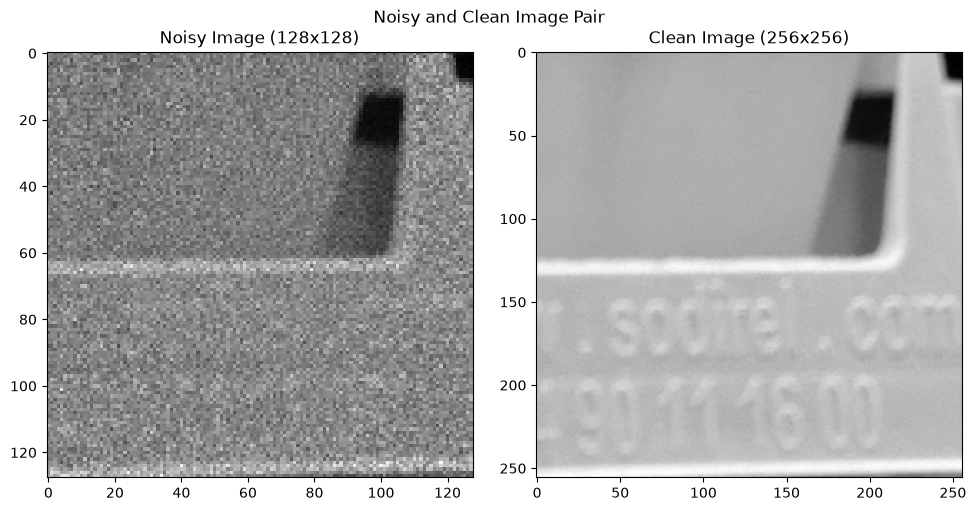

In [4]:
train_dataset = TrainImageDataset(image_dir='../data/train/train')  # Replace with your actual path
i = random.randint(0, len(train_dataset) - 1)

NoisyLR_image, GT_image = train_dataset[i]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Noisy and Clean Image Pair")
ax1.set_title(f"Noisy Image ({NoisyLR_image.shape[0]}x{NoisyLR_image.shape[1]})")
ax1.imshow(NoisyLR_image, cmap='gray')

ax2.set_title(f"Clean Image ({GT_image.shape[0]}x{GT_image.shape[1]})")
ax2.imshow(GT_image, cmap='gray')

plt.tight_layout()
plt.show()

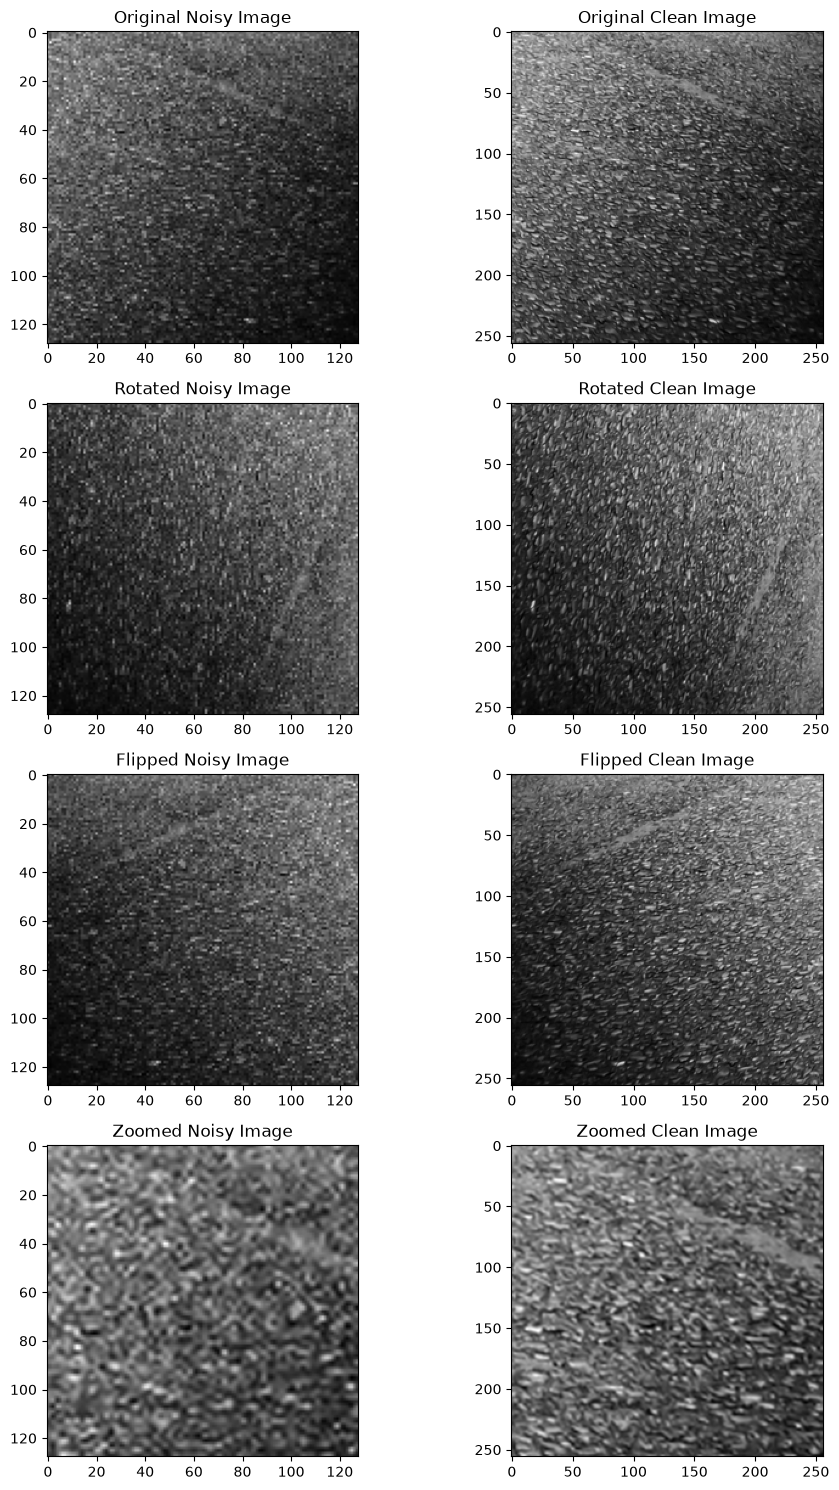

In [5]:
i = random.randint(0, len(train_dataset) - 1)
NoisyLR_image, GT_image = train_dataset[i]

random_angle = random.choice([0, 90, 180, 270])
random_axis = random.choice([0, 1])
random_offsets = (random.randint(0, 127), random.randint(0, 127))

rotated_images = rotate_image(NoisyLR_image, random_angle), rotate_image(GT_image, random_angle)
flipped_images = flip_image(NoisyLR_image, random_axis), flip_image(GT_image, random_axis)
zoomed_images = zoom_image(NoisyLR_image, scale=0.5, offset_x=random_offsets[0]//2, offset_y=random_offsets[1]//2), zoom_image(GT_image, scale=0.5, offset_x=random_offsets[0], offset_y=random_offsets[1])

fig, axes = plt.subplots(4, 2, figsize=(10, 15))
axes[0, 0].imshow(NoisyLR_image, cmap='gray')
axes[0, 0].set_title("Original Noisy Image")
axes[0, 1].imshow(GT_image, cmap='gray')
axes[0, 1].set_title("Original Clean Image")

axes[1, 0].imshow(rotated_images[0], cmap='gray')
axes[1, 0].set_title("Rotated Noisy Image")
axes[1, 1].imshow(rotated_images[1], cmap='gray')
axes[1, 1].set_title("Rotated Clean Image")

axes[2, 0].imshow(flipped_images[0], cmap='gray')
axes[2, 0].set_title("Flipped Noisy Image")
axes[2, 1].imshow(flipped_images[1], cmap='gray')
axes[2, 1].set_title("Flipped Clean Image")

axes[3, 0].imshow(zoomed_images[0], cmap='gray')
axes[3, 0].set_title("Zoomed Noisy Image")
axes[3, 1].imshow(zoomed_images[1], cmap='gray')
axes[3, 1].set_title("Zoomed Clean Image")
plt.tight_layout()
plt.show()

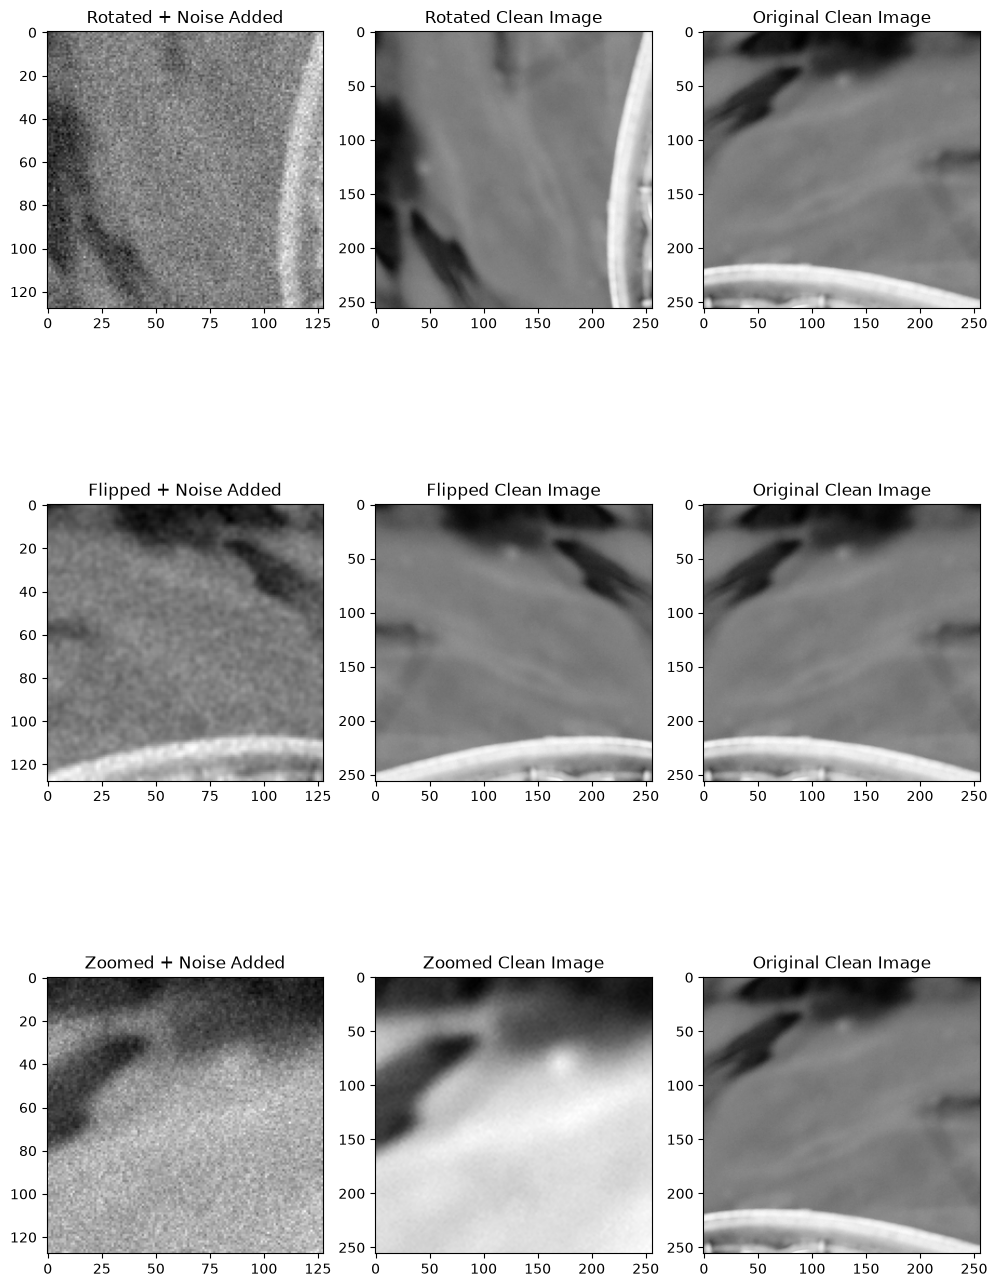

In [6]:
# Add noise to clean rotated/flipped/zoomed image
i = random.randint(0, len(train_dataset) - 1)
NoisyLR_image, GT_image = train_dataset[i]
# Apply augmentations
augmented_images = [
    rotate_image(GT_image, angle=random.choice([0, 90, 180, 270])),
    flip_image(GT_image, axis=random.choice([0, 1])),
    zoom_image(GT_image, scale=0.5, offset_x=random_offsets[0], offset_y=random_offsets[1]),
]
new_noisy_images = [
    clean_to_noisy(augmented_images[0]),
    clean_to_noisy(augmented_images[1]),
    clean_to_noisy(augmented_images[2]),
]

fig, axes = plt.subplots(3, 3, figsize=(10, 15))
axes[0, 0].imshow(new_noisy_images[0], cmap="gray")
axes[0, 0].set_title("Rotated + Noise Added")
axes[0, 1].imshow(augmented_images[0], cmap="gray")
axes[0, 1].set_title("Rotated Clean Image")
axes[0, 2].imshow(GT_image, cmap="gray")
axes[0, 2].set_title("Original Clean Image")

axes[1, 0].imshow(new_noisy_images[1], cmap="gray")
axes[1, 0].set_title("Flipped + Noise Added")
axes[1, 1].imshow(augmented_images[1], cmap="gray")
axes[1, 1].set_title("Flipped Clean Image")
axes[1, 2].imshow(GT_image, cmap="gray")
axes[1, 2].set_title("Original Clean Image")

axes[2, 0].imshow(new_noisy_images[2], cmap="gray")
axes[2, 0].set_title("Zoomed + Noise Added")
axes[2, 1].imshow(augmented_images[2], cmap="gray")
axes[2, 1].set_title("Zoomed Clean Image")
axes[2, 2].imshow(GT_image, cmap="gray")
axes[2, 2].set_title("Original Clean Image")

plt.tight_layout()
plt.show()

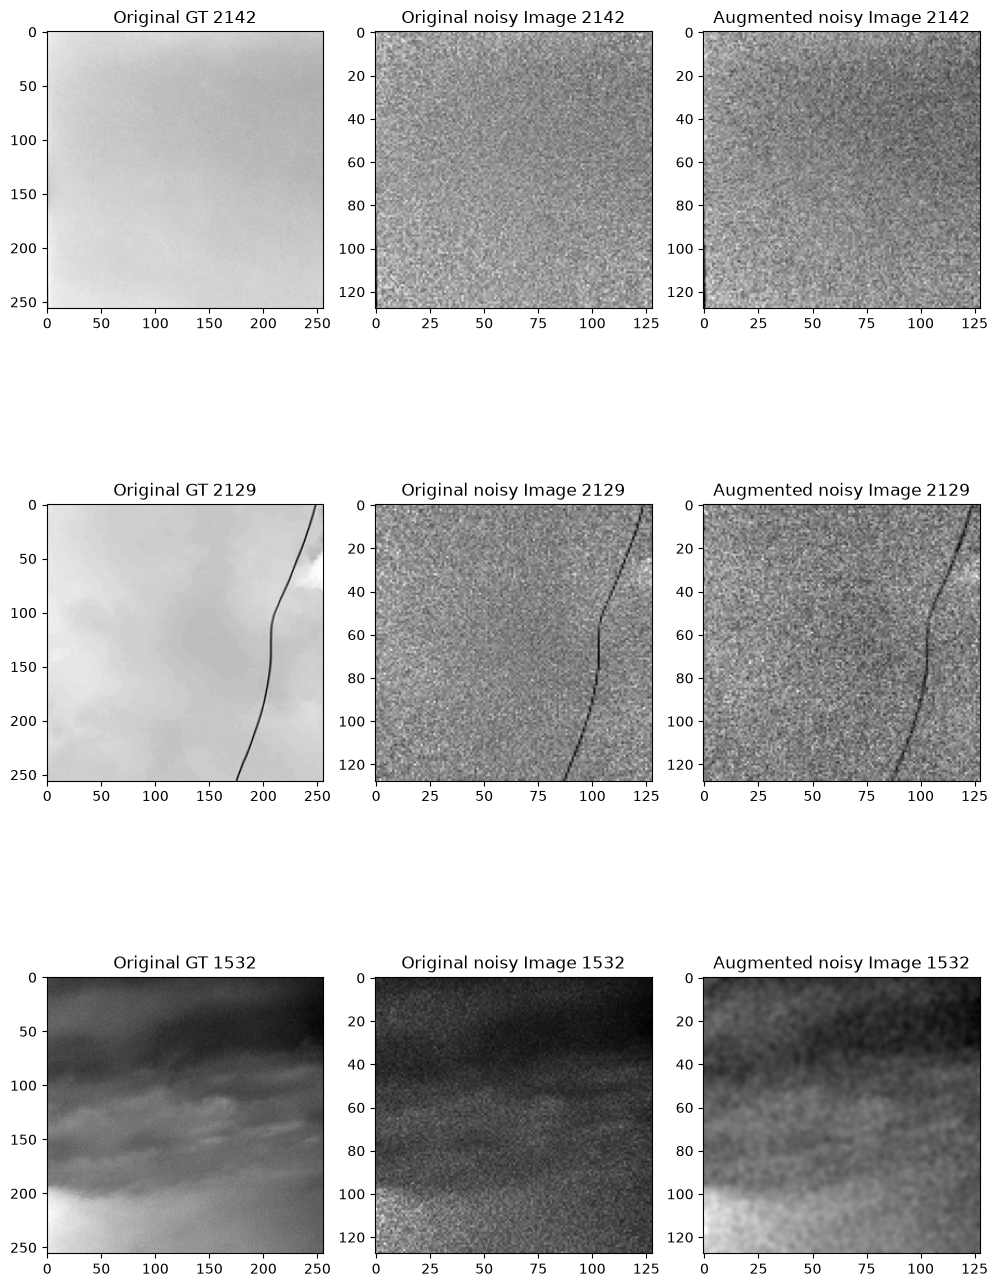

In [7]:
i_s = random.choices(list(range(len(train_dataset))), k=3)
fig, axes = plt.subplots(3, 3, figsize=(10, 15))
for idx, i in enumerate(i_s):
    NoisyLR_image, GT_image = train_dataset[i]
    axes[idx, 0].imshow(GT_image, cmap="gray")
    axes[idx, 0].set_title(f"Original GT {i}")
    axes[idx, 1].imshow(NoisyLR_image, cmap="gray")
    axes[idx, 1].set_title(f"Original noisy Image {i}")
    axes[idx, 2].imshow(clean_to_noisy(GT_image), cmap="gray")
    axes[idx, 2].set_title(f"Augmented noisy Image {i}")
plt.tight_layout()
plt.show()

In [8]:
# Perform data augmentation on the entire dataset
augmented_images = []
for NoisyLR_image, GT_image in train_dataset:
    random_angle = random.choice([0, 90, 180, 270])
    random_axis = random.choice([0, 1])
    random_offsets = (random.randint(0, 127), random.randint(0, 127))

    new_augmented_images = [
        rotate_image(GT_image, angle=random_angle),
        flip_image(GT_image, axis=random_axis),
        zoom_image(GT_image, scale=0.5, offset_x=random_offsets[0], offset_y=random_offsets[1]),
    ]
    new_noisy_images = [
        clean_to_noisy(new_augmented_images[0]),
        clean_to_noisy(new_augmented_images[1]),
        clean_to_noisy(new_augmented_images[2]),
    ]

    augmented_images.append((new_augmented_images[0], new_noisy_images[0]))
    augmented_images.append((new_augmented_images[1], new_noisy_images[1]))
    augmented_images.append((new_augmented_images[2], new_noisy_images[2]))

In [10]:
for i, (clean, noisy) in enumerate(augmented_images):  # Save the images
    assert noisy.shape == (128, 128)
    assert clean.shape == (256, 256)
    np.save(f'../data/train/augmented_new_noise/NoisyLR/{i}.npy', noisy)
    np.save(f'../data/train/augmented_new_noise/GT/{i}.npy', clean)

In [ ]:
augmented_dataset = TrainImageDataset(image_dir='../data/train/augmented_new_noise')  # Replace with your actual path

print(f"Augmented dataset size: {len(augmented_dataset)}")
print(f"Original dataset size: {len(train_dataset)}")

Augmented dataset size: 9600
Original dataset size: 3200
